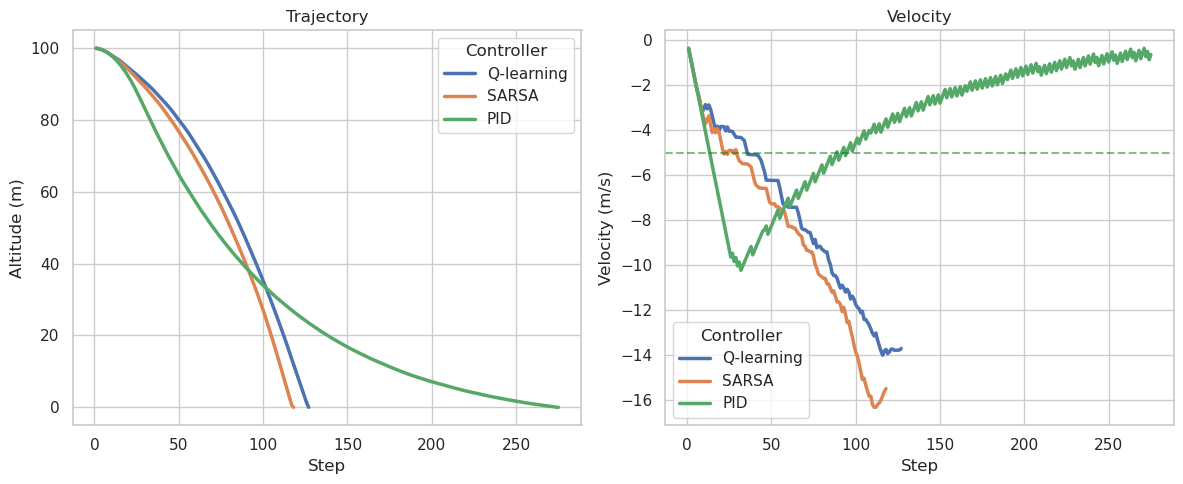

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = [12, 5]

q_df = pd.read_csv("../q_learning.csv")
s_df = pd.read_csv("../sarsa.csv")
pid_df = pd.read_csv("../pid.csv")
q_df["Controller"] = "Q-learning"
s_df["Controller"] = "SARSA"
pid_df["Controller"] = "PID"

combined_df = pd.concat([q_df, s_df, pid_df], ignore_index=True)

fig, axes = plt.subplots(1, 2)

sns.lineplot(
    data=combined_df,
    x="step",
    y="altitude",
    hue="Controller",
    ax=axes[0],
    linewidth=2.5,
)
axes[0].set_title("Trajectory")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Altitude (m)")

sns.lineplot(
    data=combined_df,
    x="step",
    y="velocity",
    hue="Controller",
    ax=axes[1],
    linewidth=2.5,
)
axes[1].axhline(-5, color="green", linestyle="--", alpha=0.5)
axes[1].set_title("Velocity")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Velocity (m/s)")

plt.tight_layout()
plt.show()

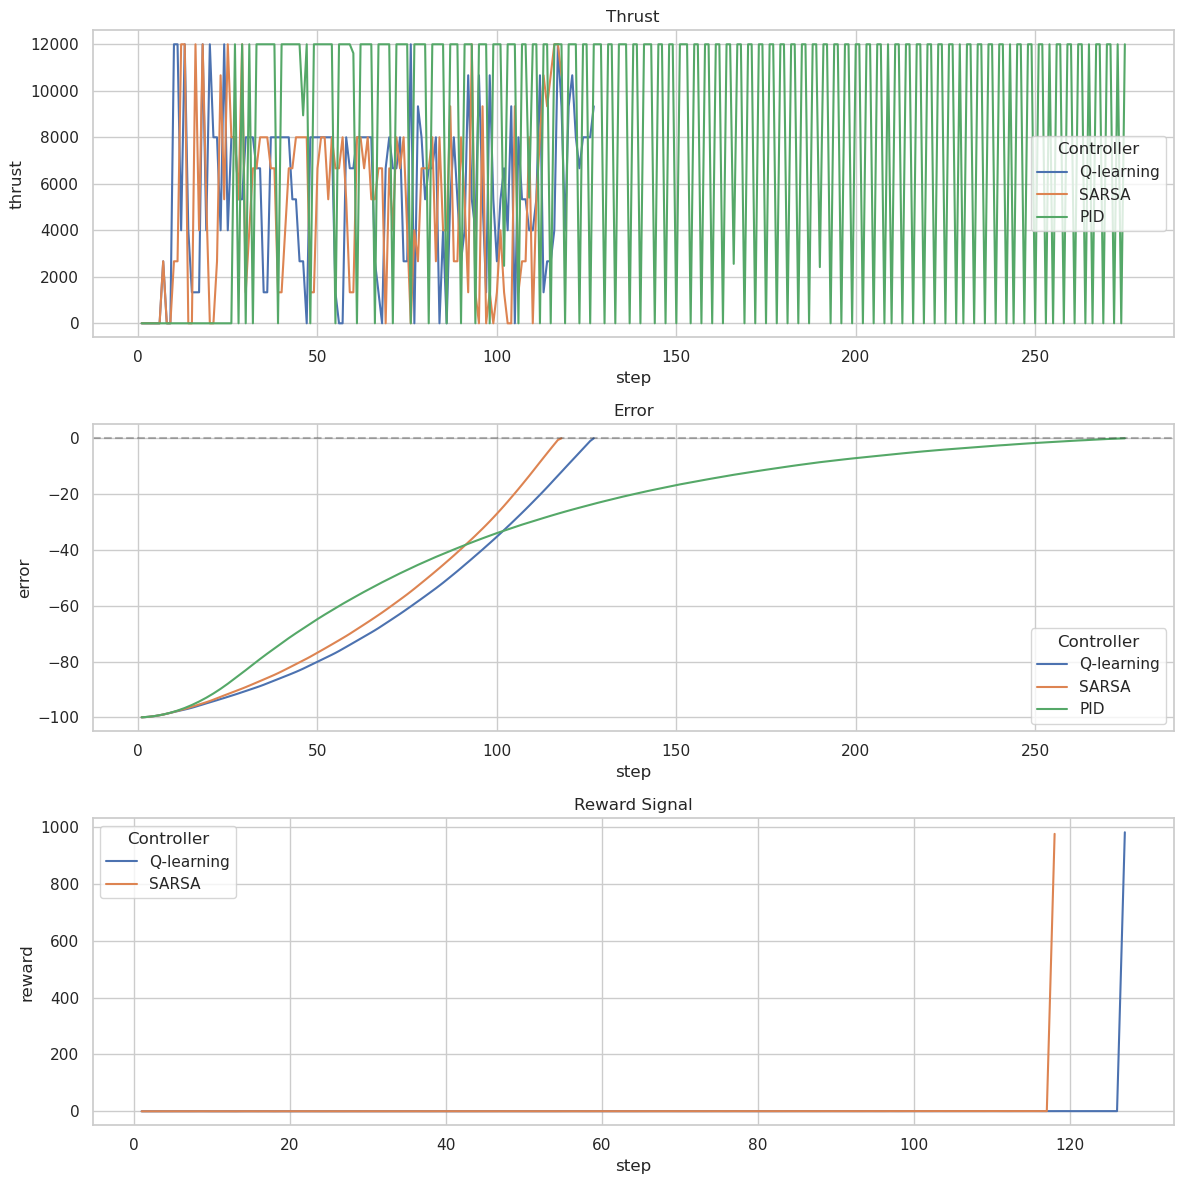

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

sns.lineplot(data=combined_df, x="step", y="thrust", hue="Controller", ax=axes[0])
axes[0].set_title("Thrust")

combined_df["error"] = -combined_df["altitude"]
sns.lineplot(data=combined_df, x="step", y="error", hue="Controller", ax=axes[1])
axes[1].axhline(0, color="k", linestyle="--", alpha=0.3)
axes[1].set_title("Error")

rl_df = combined_df[combined_df["Controller"].isin(["Q-learning", "SARSA"])]
sns.lineplot(data=rl_df, x="step", y="reward", hue="Controller", ax=axes[2])
axes[2].set_title("Reward Signal")

plt.tight_layout()
plt.show()